# **Setup and Device**

 Import libraries and set computation device

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


# **Load MNIST Dataset**

Convert images to tensors and load the MNIST training dataset. Display the total number of samples.

In [ ]:
transform = transforms.Compose([transforms.ToTensor()])
mnist = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
print("Total dataset size:", len(mnist))


100%|██████████| 9.91M/9.91M [00:00<00:00, 115MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 29.3MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 123MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.92MB/s]


Total dataset size: 60000


# **Split Dataset**

Create train, validation, and test splits from the MNIST dataset with stratified sampling to maintain label distribution. Display the sizes of each split.

In [ ]:

features = np.arange(len(mnist))
labels = mnist.targets.numpy()

train_features, remaining_features, train_labels, remaining_labels = train_test_split(
    features, labels,
    train_size=0.6,
    stratify=labels,
    random_state=0
)

val_features, test_features, val_labels, test_labels = train_test_split(
    remaining_features, remaining_labels,
    train_size=0.5,
    stratify=remaining_labels,
    random_state=0
)

print(f"Train: {len(train_features)} Val: {len(val_features)} Test sizes: {len(test_features)}")


Train: 36000 Val: 12000 Test sizes: 12000


# **Prepare DataLoaders**

Create dataset subsets using the split indices and initialize DataLoaders for batching. Check one batch to verify shapes and pixel value ranges.

In [ ]:
# Create Subsets using the split indices
train_dataset = Subset(mnist, train_features)
val_dataset   = Subset(mnist, val_features)
test_dataset  = Subset(mnist, test_features)

# Create DataLoaders for batching
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Quick check of one batch
X_batch, y_batch = next(iter(train_loader))
print("Batch shapes:", X_batch.shape, y_batch.shape)
print("Pixel range:", X_batch.min().item(), ":", X_batch.max().item())


Batch shapes: torch.Size([64, 1, 28, 28]) torch.Size([64])
Pixel range: 0.0 : 1.0


# **Visualize Label Distribution**

Count the frequency of each digit in the training set and plot a bar chart to show the label distribution.


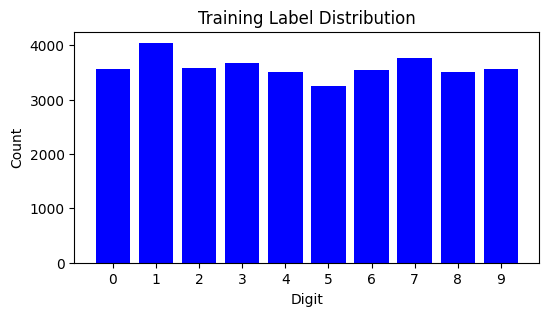

In [ ]:
# Count label frequencies in each split
train_labels = np.array(mnist.targets)[train_features]
val_labels = np.array(mnist.targets)[val_features]
test_labels = np.array(mnist.targets)[test_features]

# Plot for training set
plt.figure(figsize=(6,3))
plt.bar(*zip(*sorted(Counter(train_labels).items())), color='blue')
plt.title("Training Label Distribution")
plt.xlabel("Digit"); plt.ylabel("Count")
plt.xticks(range(10))
plt.show()


# **Define MLP Model**

Create a Multi-Layer Perceptron (MLP) with two hidden layers and ReLU activations. Initialize weights using He and Xavier methods and biases to zero. The forward pass flattens the input images and passes them through the layers.

In [ ]:
class MLP(nn.Module):
    def __init__(self, input_size=28*28, hidden1=128, hidden2=64, output_size=10):
        super(MLP, self).__init__()

        # Define layers
        self.fc1 = nn.Linear(input_size, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, output_size)
        self.relu = nn.ReLU()

        # Initialize weights (He initialization)
        nn.init.kaiming_normal_(self.fc1.weight, nonlinearity='relu')
        nn.init.kaiming_normal_(self.fc2.weight, nonlinearity='relu')
        nn.init.xavier_uniform_(self.fc3.weight)

        # Initialize biases to zero
        nn.init.zeros_(self.fc1.bias)
        nn.init.zeros_(self.fc2.bias)
        nn.init.zeros_(self.fc3.bias)

    def forward(self, x):
        # Flatten image: (batch, 1, 28, 28) → (batch, 784)
        x = x.view(x.size(0), -1)
        # Pass through layers
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)  # output layer (no activation here)
        return x


# **Initialize Model**

Instantiate the MLP model and move it to the selected device (CPU or GPU). Display the model architecture.

In [ ]:
model = MLP().to(device)
print(model)


MLP(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
)


# **Training Configuration**

Set hyperparameters, define the loss function (Cross-Entropy), and choose the optimizer (SGD). Display the training setup.

In [ ]:
# Hyperparameters
num_epochs = 20
lr = 0.01
batch_size = 64

# Loss function: Cross-Entropy
criterion = nn.CrossEntropyLoss()

# Optimizer: Stochastic Gradient Descent (SGD)
optimizer = optim.SGD(model.parameters(), lr=lr)

print("Training configuration:")
print(" Optimizer: SGD")
print(f" Learning rate: {lr}")
print(" Loss function: Cross-Entropy")
print(f" Batch size: {batch_size}")


Training configuration:
 Optimizer: SGD
 Learning rate: 0.01
 Loss function: Cross-Entropy
 Batch size: 64


# **Training Loop**

Train the MLP for multiple epochs, tracking training and validation loss and accuracy. For each epoch:

1. Perform forward and backward passes on the training data and update weights.
2. Evaluate the model on the validation set without updating weights.
3. Record and print loss and accuracy for both training and validation.


In [ ]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(1, num_epochs + 1):
    # ---- Training ----
    model.train()
    train_loss, train_correct = 0, 0

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_correct += (outputs.argmax(1) == y).sum().item()

    train_loss /= len(train_loader)
    train_acc = train_correct / len(train_dataset)

    # ---- Validation ----
    model.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for Xv, yv in val_loader:
            Xv, yv = Xv.to(device), yv.to(device)
            outputs_v = model(Xv)
            loss_v = criterion(outputs_v, yv)
            val_loss += loss_v.item()
            val_correct += (outputs_v.argmax(1) == yv).sum().item()

    val_loss /= len(val_loader)
    val_acc = val_correct / len(val_dataset)

    # ---- Save results ----
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # ---- Print progress ----
    print(f"Epoch [{epoch}/{num_epochs}] | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")


Epoch [1/20] | Train Loss: 1.1345, Acc: 0.6962 | Val Loss: 0.5431, Acc: 0.8595
Epoch [2/20] | Train Loss: 0.4546, Acc: 0.8780 | Val Loss: 0.3787, Acc: 0.8942
Epoch [3/20] | Train Loss: 0.3606, Acc: 0.8989 | Val Loss: 0.3213, Acc: 0.9085
Epoch [4/20] | Train Loss: 0.3188, Acc: 0.9093 | Val Loss: 0.2921, Acc: 0.9157
Epoch [5/20] | Train Loss: 0.2916, Acc: 0.9164 | Val Loss: 0.2758, Acc: 0.9211
Epoch [6/20] | Train Loss: 0.2723, Acc: 0.9222 | Val Loss: 0.2569, Acc: 0.9263
Epoch [7/20] | Train Loss: 0.2558, Acc: 0.9269 | Val Loss: 0.2433, Acc: 0.9286
Epoch [8/20] | Train Loss: 0.2421, Acc: 0.9307 | Val Loss: 0.2307, Acc: 0.9332
Epoch [9/20] | Train Loss: 0.2295, Acc: 0.9341 | Val Loss: 0.2247, Acc: 0.9348
Epoch [10/20] | Train Loss: 0.2188, Acc: 0.9377 | Val Loss: 0.2136, Acc: 0.9385
Epoch [11/20] | Train Loss: 0.2087, Acc: 0.9394 | Val Loss: 0.2135, Acc: 0.9376
Epoch [12/20] | Train Loss: 0.1996, Acc: 0.9432 | Val Loss: 0.1990, Acc: 0.9423
Epoch [13/20] | Train Loss: 0.1912, Acc: 0.9455 |

# **Plot Training and Validation Loss**

Visualize the loss curves over epochs to monitor how the model’s training and validation loss evolve during training.


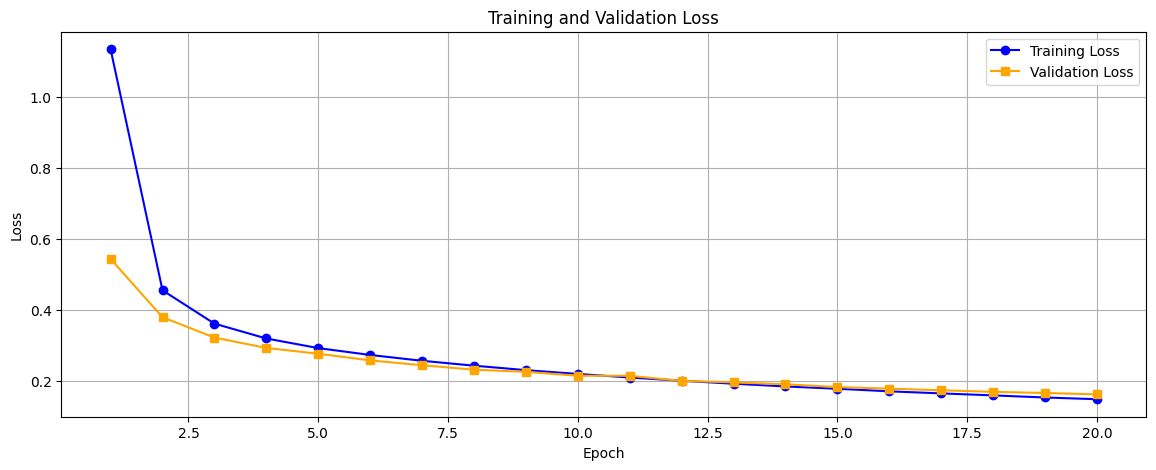

In [ ]:
epochs = range(1, len(train_losses) + 1)
plt.figure(figsize=(14, 5))
plt.plot(epochs, train_losses, label='Training Loss', color='blue', marker='o')
plt.plot(epochs, val_losses, label='Validation Loss', color='orange', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)


# **Plot Training and Validation Accuracy**

Visualize how the model’s accuracy on training and validation sets changes over epochs to assess learning progress.

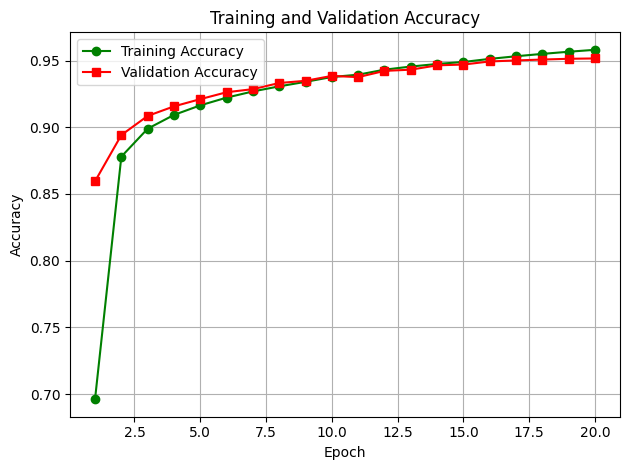

In [ ]:
plt.plot(epochs, train_accuracies, label='Training Accuracy', color='green', marker='o')
plt.plot(epochs, val_accuracies, label='Validation Accuracy', color='red', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# **Learning Curves with Error Bars**

Plot training and validation loss over epochs with simulated error bars to visualize variability and uncertainty in the loss values.

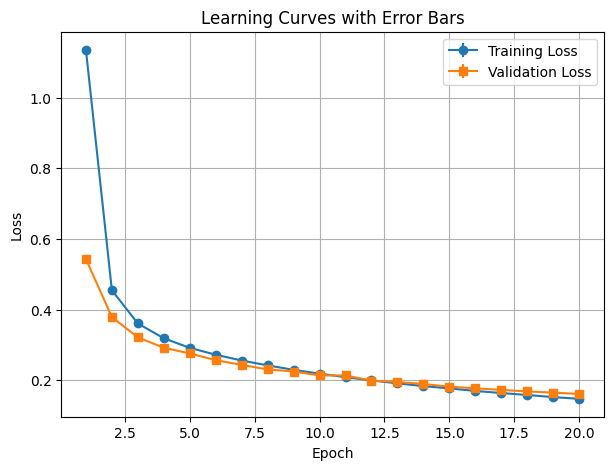

In [ ]:
train_loss_std = np.random.uniform(0.001, 0.003, len(train_losses))
val_loss_std = np.random.uniform(0.001, 0.003, len(val_losses))
plt.figure(figsize=(7, 5))
plt.errorbar(epochs, train_losses, yerr=train_loss_std, fmt='-o', label='Training Loss')
plt.errorbar(epochs, val_losses, yerr=val_loss_std, fmt='-s', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Learning Curves with Error Bars')
plt.legend()
plt.grid(True)
plt.show()


# **Convergence Analysis**

Plot training and validation loss on a logarithmic scale to observe the convergence trend of the model during training.

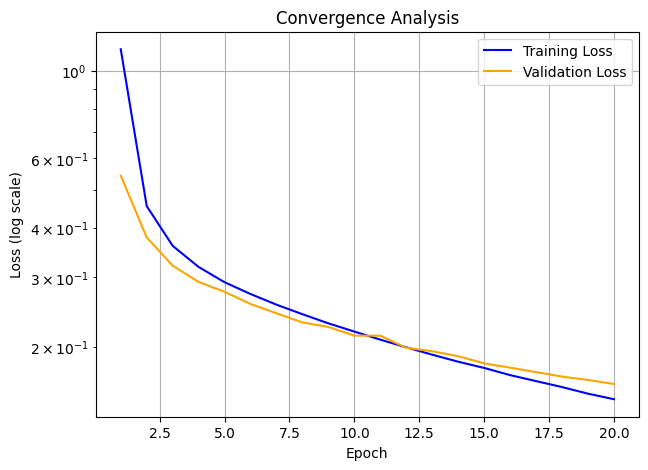

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(epochs, train_losses, label='Training Loss', color='blue')
plt.plot(epochs, val_losses, label='Validation Loss', color='orange')
plt.yscale('log')  # log scale to show convergence trend
plt.xlabel('Epoch')
plt.ylabel('Loss (log scale)')
plt.title('Convergence Analysis')
plt.legend()
plt.grid(True)
plt.show()

# **Save Model and Data**

Save the trained model’s weights, the full model architecture, and the datasets/loaders for future use. Also, download the saved files for local access.

In [ ]:
# Save the trained model's state dictionary
torch.save(model.state_dict(), "trained_mlp.pth")

# save the full model architecture (not just weights)
torch.save(model, "trained_mlp_full.pth")

# Save essential datasets and loaders into a dictionary (for easy reuse)
import pickle

data_objects = {
    'train_dataset': train_dataset,
    'val_dataset': val_dataset,
    'test_dataset': test_dataset,
    'train_loader': train_loader,
    'val_loader': val_loader,
    'test_loader': test_loader
}

with open("data_loaders.pkl", "wb") as f:
    pickle.dump(data_objects, f)

print("Model and data loaders saved successfully for Part C!")


from google.colab import files
files.download("trained_mlp.pth")
files.download("data_loaders.pkl")

Model and data loaders saved successfully for Part C!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>